In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
X_simple = np.random.rand(100, 1) * 10
y_simple = 3 * X_simple + 7 + np.random.randn(100, 1) * 2
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)
simple_lr = LinearRegression()
simple_lr.fit(X_train, y_train)

LinearRegression()

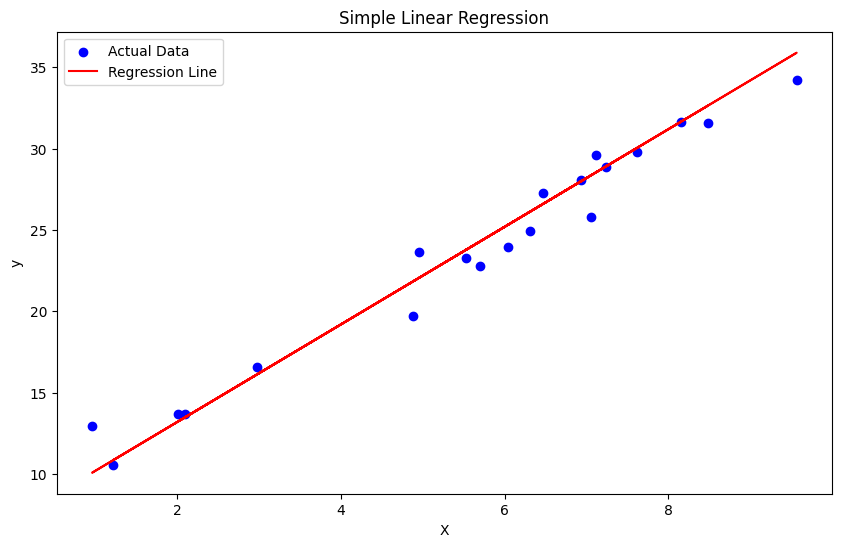

In [5]:
y_pred_simple = simple_lr.predict(X_test)
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred_simple, color='red', label='Regression Line')
plt.title('Simple Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

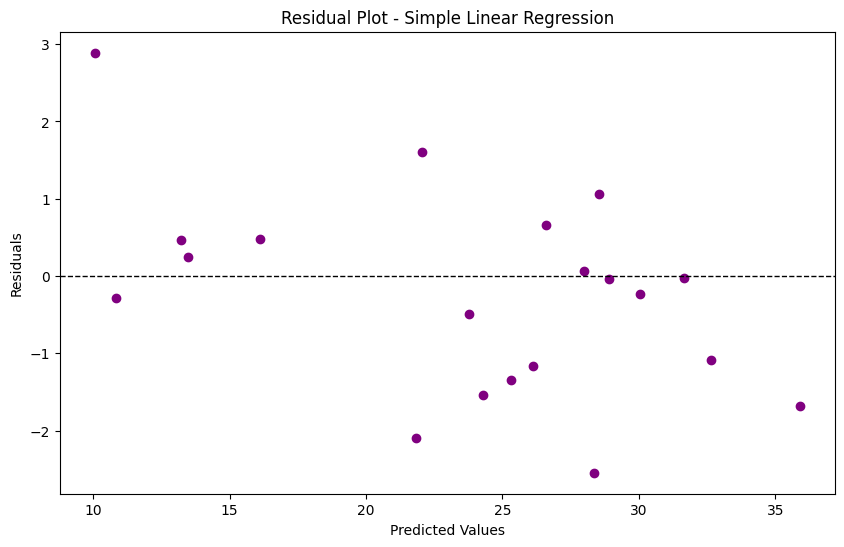

In [6]:
residuals_simple = y_test - y_pred_simple
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_simple, residuals_simple, color='purple')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot - Simple Linear Regression')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

In [8]:
print("Simple Linear Regression Metrics:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_simple):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_simple):.2f}\n")


Simple Linear Regression Metrics:
Mean Squared Error: 1.69
R2 Score: 0.96



Logistic regression


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
confusion_matrix,
roc_curve,
auc,
classification_report,
)


In [12]:
np.random.seed(42)
X = np.random.rand(200, 2) * 10
y = (4 * X[:, 0] - 3 * X[:, 1] + np.random.randn(200) > 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [13]:
y_pred = log_reg.predict(X_test)
y_pred_prob = log_reg.predict_proba(X_test)[:, 1]

In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Accuracy: 0.98
Precision: 0.97
Recall: 1.00


In [15]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)



Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        22
           1       0.97      1.00      0.99        38

    accuracy                           0.98        60
   macro avg       0.99      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60


Confusion Matrix:
 [[21  1]
 [ 0 38]]


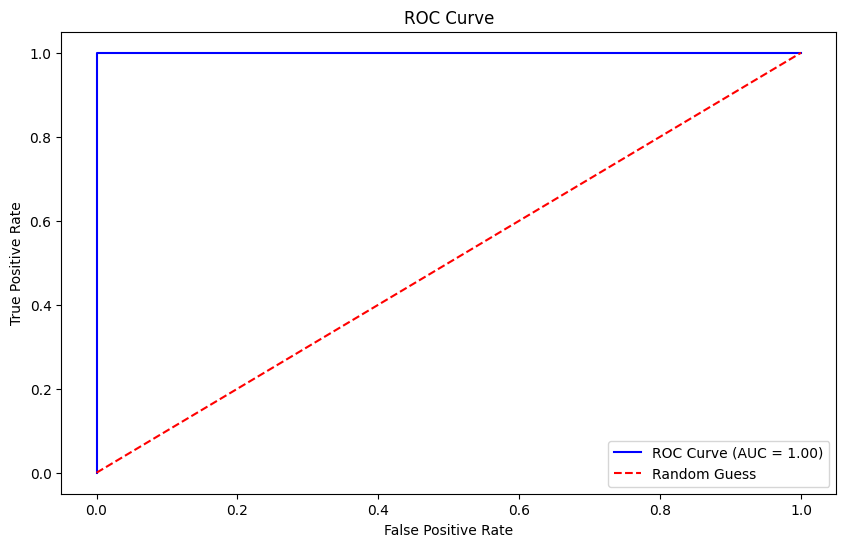

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob) # False Positive Rate, True Positive Rate
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color="blue", label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
